In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import zipfile

zip_path = "/content/drive/MyDrive/CRPF_IMAGES.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [12]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root, len(files))

/content/dataset 0
/content/dataset/3_Specimen image 892
/content/dataset/5_Compression after impact strength 1
/content/dataset/1_Low velocity impact testing condition 0


In [14]:
import os

path = "/content/dataset/1_Low velocity impact testing condition"

for root, dirs, files in os.walk(path):
    print(root)
    print("Dirs:", dirs)
    print("Files:", files)
    print("-"*40)

/content/dataset/1_Low velocity impact testing condition
Dirs: []
Files: []
----------------------------------------


In [15]:
import os

print(os.listdir("/content/dataset/5_Compression after impact strength"))

['Compression after impact strength_v0.2.xlsx']


In [16]:
import pandas as pd

excel_path = "/content/dataset/5_Compression after impact strength/Compression after impact strength_v0.2.xlsx"

df = pd.read_excel(excel_path)

print(df.head())
print(df.columns)

   Unnamed: 0    Unnamed: 1                         Unnamed: 2 Unnamed: 3
0         NaN  Specimen No.  Compression after impact strength        NaN
1         NaN           NaN                              [Mpa]        [%]
2         NaN         c8-6t                         199.801865   0.720235
3         NaN         c8-8t                         216.368547   0.779954
4         NaN         c8-9t                         190.131233   0.685375
Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3'], dtype='object')


In [17]:
import pandas as pd

excel_path = "/content/dataset/5_Compression after impact strength/Compression after impact strength_v0.2.xlsx"

df = pd.read_excel(excel_path)

# Drop first 2 rows (junk header + units)
df = df.iloc[2:]

# Rename columns properly
df.columns = ["ignore", "Specimen_ID", "CAI_strength", "Reduction"]

# Drop useless column
df = df.drop(columns=["ignore"])

# Reset index
df = df.reset_index(drop=True)

print(df.head())

  Specimen_ID CAI_strength Reduction
0       c8-6t   199.801865  0.720235
1       c8-8t   216.368547  0.779954
2       c8-9t   190.131233  0.685375
3      c8-10t   204.172332   0.73599
4      c8-11t   262.598682  0.946602


In [18]:
df["Specimen_ID"] = df["Specimen_ID"].str.replace("t", "")

In [19]:
import os

img_folder = "/content/dataset/3_Specimen image"

images = os.listdir(img_folder)

data = []

for img in images:
    specimen_id = img.split(".")[0]

    row = df[df["Specimen_ID"] == specimen_id]

    if len(row) > 0:
        strength = row["CAI_strength"].values[0]
        data.append((img, strength))

print("✅ Matched samples:", len(data))

✅ Matched samples: 0


In [20]:
print("Excel IDs:")
print(df["Specimen_ID"].head(10).tolist())

import os
images = os.listdir("/content/dataset/3_Specimen image")

print("\nImage names:")
print(images[:10])

Excel IDs:
['c8-6', 'c8-8', 'c8-9', 'c8-10', 'c8-11', 'c8-12', 'c24-6', 'c24-8', 'c24-9', 'c24-10']

Image names:
['q16-49_back.jpg', 'c16-23_back.jpg', 'q8-35_back.jpg', 'c8-25_front.jpg', 'q8-28_front.jpg', 'c8-9_back.jpg', 'c8-11_front.jpg', 'q8-28_back.jpg', 'c8-46_front.jpg', 'q8-8_front.jpg']


In [21]:
clean_images = []

for img in images:
    name = img.split(".")[0]

    # Remove suffix
    name = name.replace("_front", "")
    name = name.replace("_back", "")

    name = name.strip().lower()

    clean_images.append((img, name))

In [22]:
data = []

for img, clean_name in clean_images:
    row = df[df["Specimen_ID"] == clean_name]

    if len(row) > 0:
        strength = row["CAI_strength"].values[0]
        data.append((img, strength))

print("✅ Matched samples:", len(data))

✅ Matched samples: 868


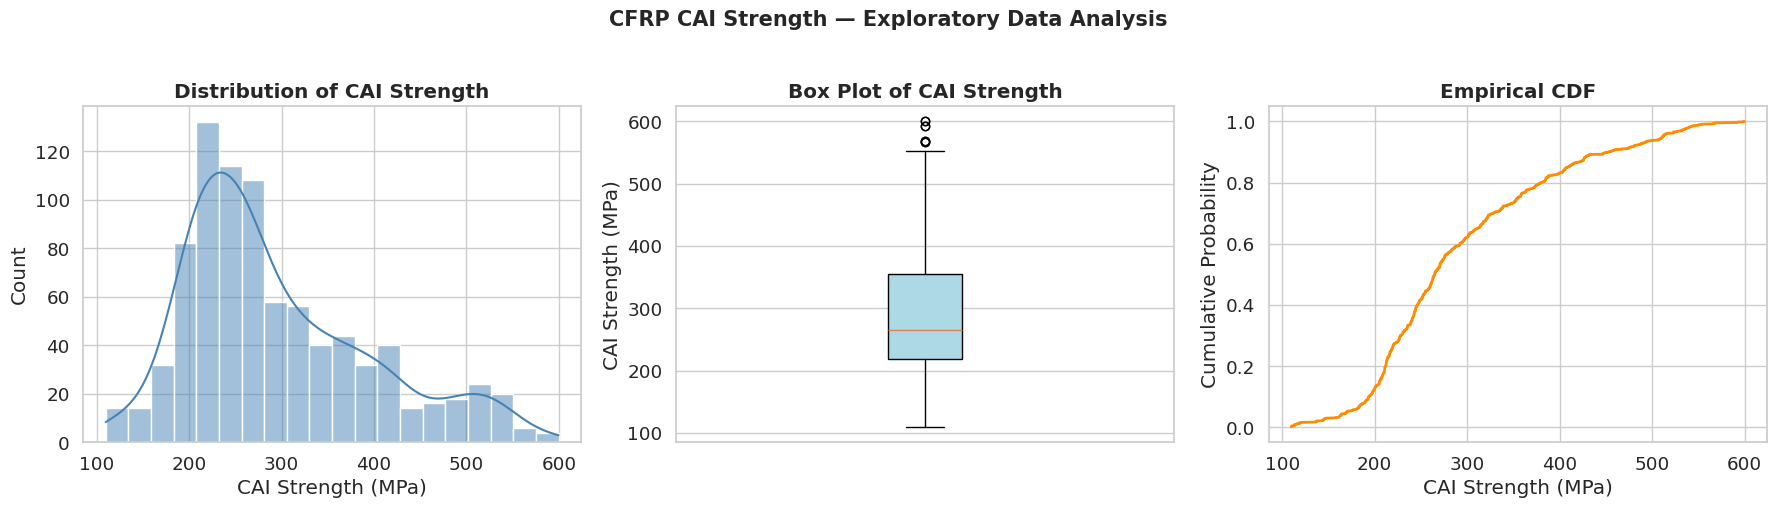


Strength stats (MPa):
  Min   = 109.75
  Max   = 599.57
  Mean  = 294.71
  Std   = 101.79
  Count = 868


In [51]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.2)

# Fix: Create a DataFrame from the 'data' list
dataset_df = pd.DataFrame(data, columns=['image_name', 'strength_MPa'])
strengths = dataset_df["strength_MPa"].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram + KDE
sns.histplot(strengths, bins=20, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of CAI Strength", fontweight='bold')
axes[0].set_xlabel("CAI Strength (MPa)")
axes[0].set_ylabel("Count")

# 2. Box plot
axes[1].boxplot(strengths, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title("Box Plot of CAI Strength", fontweight='bold')
axes[1].set_ylabel("CAI Strength (MPa)")
axes[1].set_xticks([])

# 3. Cumulative distribution
sorted_s = np.sort(strengths)
cdf = np.arange(1, len(sorted_s)+1) / len(sorted_s)
axes[2].plot(sorted_s, cdf, lw=2, color='darkorange')
axes[2].set_title("Empirical CDF", fontweight='bold')
axes[2].set_xlabel("CAI Strength (MPa)")
axes[2].set_ylabel("Cumulative Probability")

plt.suptitle("CFRP CAI Strength — Exploratory Data Analysis",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("eda.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nStrength stats (MPa):")
print(f"  Min   = {strengths.min():.2f}")
print(f"  Max   = {strengths.max():.2f}")
print(f"  Mean  = {strengths.mean():.2f}")
print(f"  Std   = {strengths.std():.2f}")
print(f"  Count = {len(strengths)}")

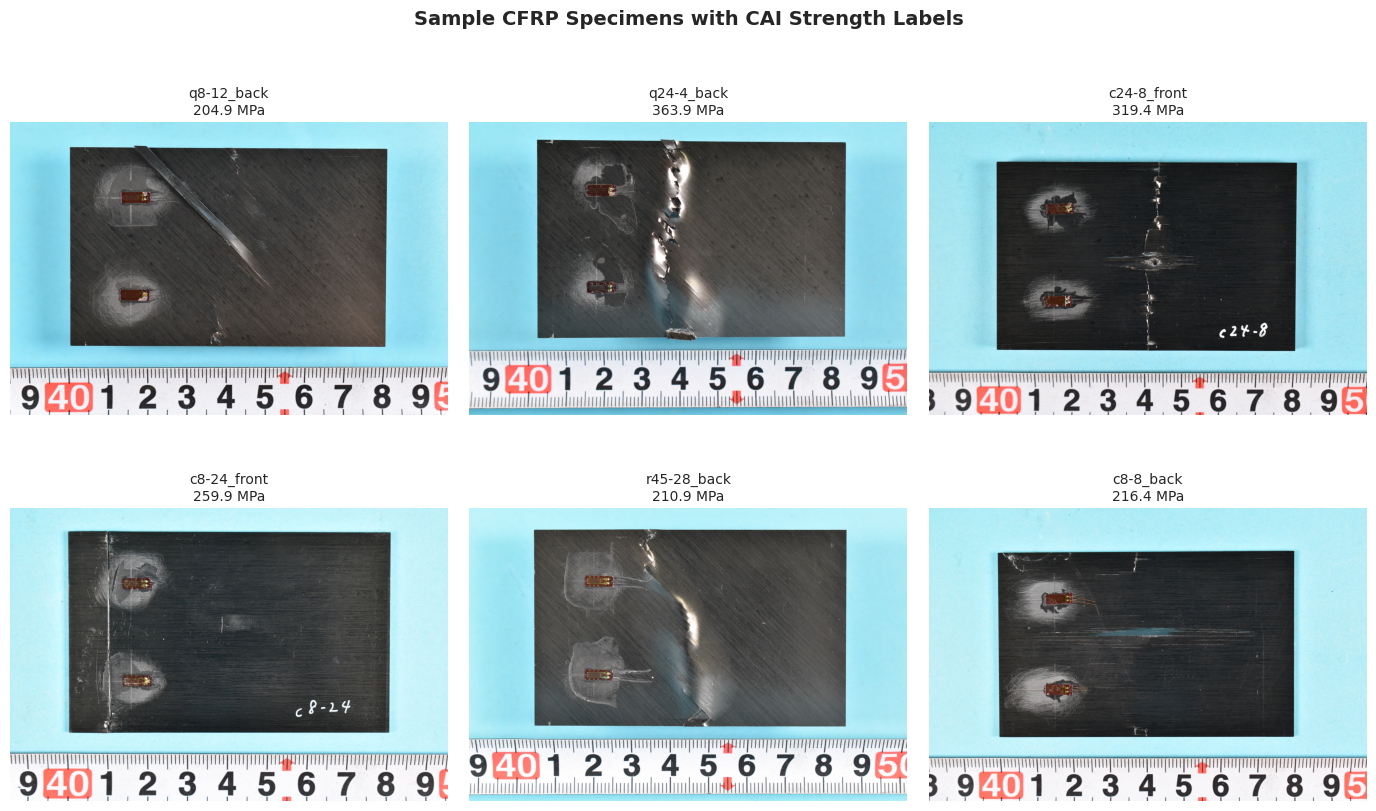

In [53]:
# ── Sample image grid ───────────────────────────────────────
SEED = 42 # Define SEED for reproducibility
sample_rows = dataset_df.sample(6, random_state=SEED)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    img_path = os.path.join(img_folder, row["image_name"]) # Use img_folder from earlier code
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{row['image_name'].split('.')[0]}\n{row['strength_MPa']:.1f} MPa",
                 fontsize=10)
    ax.axis('off')

plt.suptitle("Sample CFRP Specimens with CAI Strength Labels",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import os

# Add the full image path to the dataset_df
dataset_df["img_path"] = dataset_df["image_name"].apply(lambda x: os.path.join(img_folder, x))

# ── Stratified split via strength quantile bins ────────────────────
dataset_df["_strat_bin"] = pd.qcut(
    dataset_df["strength_MPa"], q=5, labels=False, duplicates='drop'
)

train_df, temp_df = train_test_split(
    dataset_df, test_size=0.20, random_state=SEED,
    stratify=dataset_df["_strat_bin"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED,
    stratify=temp_df["_strat_bin"]
)

for name, subset in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name:5s}: {len(subset):4d} samples | "
          f"μ={subset['strength_MPa'].mean():.2f} MPa | "
          f"σ={subset['strength_MPa'].std():.2f} MPa")

# ── Fit scaler ONLY on training labels (no leakage) ────────────────────
scaler = MinMaxScaler()
y_train_raw = train_df["strength_MPa"].values.reshape(-1, 1)
y_val_raw   = val_df["strength_MPa"].values.reshape(-1, 1)
y_test_raw  = test_df["strength_MPa"].values.reshape(-1, 1)

y_train = scaler.fit_transform(y_train_raw)   # fit here only
y_val   = scaler.transform(y_val_raw)
y_test  = scaler.transform(y_test_raw)

Train:  694 samples | μ=294.76 MPa | σ=102.99 MPa
Val  :   87 samples | μ=295.92 MPa | σ=96.25 MPa
Test :   87 samples | μ=293.14 MPa | σ=99.18 MPa


In [57]:
IMG_SIZE  = 224
BATCH_SIZE = 16

# ── Image loading ──────────────────────────────────────────────────────────────
def load_images(paths: list) -> np.ndarray:
    """Load, resize, and normalise to [0, 1]."""
    imgs = []
    for p in paths:
        img = cv2.imread(p)
        if img is None:
            raise FileNotFoundError(f"Cannot read: {p}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE),
                         interpolation=cv2.INTER_AREA)
        imgs.append(img.astype(np.float32) / 255.0)
    return np.array(imgs, dtype=np.float32)

print("Loading training images   …", end=" ")
X_train = load_images(train_df["img_path"].tolist()); print(X_train.shape)

print("Loading validation images …", end=" ")
X_val = load_images(val_df["img_path"].tolist()); print(X_val.shape)

print("Loading test images       …", end=" ")
X_test = load_images(test_df["img_path"].tolist()); print(X_test.shape)

Loading training images   … (694, 224, 224, 3)
Loading validation images … (87, 224, 224, 3)
Loading test images       … (87, 224, 224, 3)


In [58]:
# ── tf.data pipeline with augmentation (train only) ───────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

@tf.function
def augment(image, label):
    """Light augmentation relevant for microscopy / specimen images."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.10)
    image = tf.image.random_contrast(image, lower=0.85, upper=1.15)
    # Random 0°/90°/180°/270° rotation
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def make_dataset(X, y, augment_data=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(X_train, y_train, augment_data=True,  shuffle=True)
val_ds   = make_dataset(X_val,   y_val,   augment_data=False, shuffle=False)
test_ds  = make_dataset(X_test,  y_test,  augment_data=False, shuffle=False)

print("Datasets ready.")

Datasets ready.


In [59]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)

def build_model(freeze_base: bool = True) -> tf.keras.Model:
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = not freeze_base

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    # MobileNetV2 expects inputs in [-1, 1]; apply preprocessing
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base(x, training=False)  # training=False keeps BN in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='linear', name='cai_strength')(x)

    model = models.Model(inputs, output)
    return model

model = build_model(freeze_base=True)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='huber',          # robust to outliers vs pure MSE
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cai_strength (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,065 (10.01 MB)

 Trainable params: 363,521 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [60]:

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_phase1.weights.h5',
                    monitor='val_loss', save_best_only=True,
                    save_weights_only=True, verbose=0),
    CSVLogger('training_phase1.csv')
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_phase1,
    verbose=1
)

print("Phase 1 complete.")

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 746ms/step - loss: 0.2522 - mae: 0.4954 - rmse: 0.6538 - val_loss: 0.0756 - val_mae: 0.1565 - val_rmse: 0.2126 - learning_rate: 0.0010
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 677ms/step - loss: 0.1453 - mae: 0.3424 - rmse: 0.4332 - val_loss: 0.0707 - val_mae: 0.1559 - val_rmse: 0.1982 - learning_rate: 0.0010
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 677ms/step - loss: 0.1032 - mae: 0.2543 - rmse: 0.3243 - val_loss: 0.0769 - val_mae: 0.1677 - val_rmse: 0.2319 - learning_rate: 0.0010
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 661ms/step - loss: 0.0883 - mae: 0.2179 - rmse: 0.2792 - val_loss: 0.0962 - val_mae: 0.2430 - val_rmse: 0.3087 - learning_rate: 0.0010
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 31s 695ms/step - loss: 0.0837 - mae: 0.2068 - rmse: 0.2676 - val_loss: 0.0959 - val_mae: 0.2490 - val_rmse: 0.3120 - learning_rate: 0.0010
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - loss: 0.0774 - mae: 0.1900 - rmse: 0.2468
Epoch 6: ReduceLROn

In [63]:
# Unfreeze only the last 40 layers of the base
base_model = model.layers[1]   # MobileNetV2 block (corrected index)
base_model.trainable = True

UNFREEZE_FROM = len(base_model.layers) - 40
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after fine-tune setup: {trainable_count}")

# Recompile with much lower LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='huber',
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_phase2.weights.h5',
                    monitor='val_loss', save_best_only=True,
                    save_weights_only=True, verbose=0),
    CSVLogger('training_phase2.csv')
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks_phase2,
    verbose=1
)

print("Phase 2 complete.")

Trainable layers after fine-tune setup: 9
Epoch 1/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.1843 - mae: 0.4035 - rmse: 0.5235 - val_loss: 0.1197 - val_mae: 0.3336 - val_rmse: 0.3705 - learning_rate: 1.0000e-05
Epoch 2/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - loss: 0.1879 - mae: 0.4095 - rmse: 0.5307 - val_loss: 0.2845 - val_mae: 0.6534 - val_rmse: 0.6833 - learning_rate: 1.0000e-05
Epoch 3/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - loss: 0.1564 - mae: 0.3601 - rmse: 0.4617 - val_loss: 0.5565 - val_mae: 0.9917 - val_rmse: 1.0126 - learning_rate: 1.0000e-05
Epoch 4/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - loss: 0.1742 - mae: 0.3947 - rmse: 0.5027 - val_loss: 0.7817 - val_mae: 1.2282 - val_rmse: 1.2450 - learning_rate: 1.0000e-05
Epoch 5/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - loss: 0.1566 - mae: 0.3651 - rmse: 0.4608 - val_loss: 1.1237 - val_mae: 1.5726 - val_rmse: 1.5862 - learning_rate: 1.0000e-05
Epoch 6/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.1548 - ma

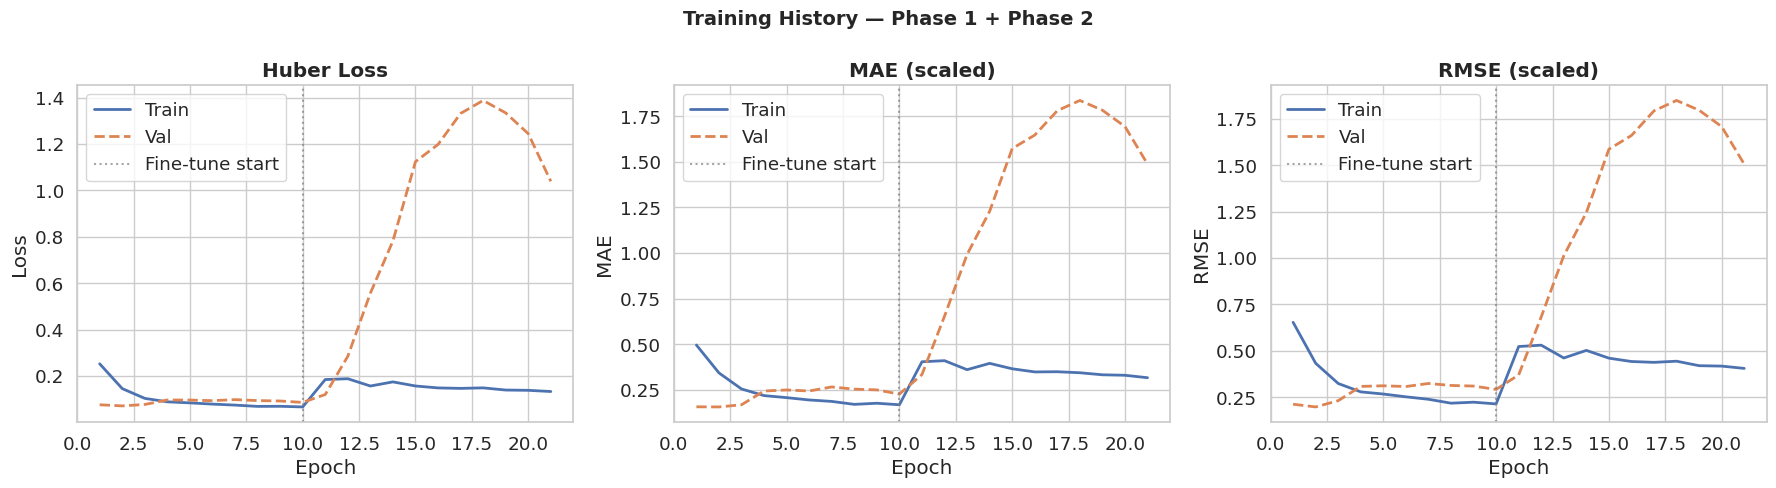

In [64]:
def merge_histories(h1, h2):
    """Concatenate two Keras History objects into one dict."""
    combined = {}
    for k in h1.history:
        combined[k] = h1.history[k] + h2.history[k]
    return combined

hist = merge_histories(history1, history2)
phase1_end = len(history1.history['loss'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_map = [
    ('loss',  'Huber Loss',  'Loss'),
    ('mae',   'MAE (scaled)','MAE'),
    ('rmse',  'RMSE (scaled)','RMSE'),
]

for ax, (key, title, ylabel) in zip(axes, metric_map):
    epochs = range(1, len(hist[key]) + 1)
    ax.plot(epochs, hist[key],     label='Train', lw=2)
    ax.plot(epochs, hist[f'val_{key}'], label='Val',   lw=2, ls='--')
    ax.axvline(phase1_end, color='gray', ls=':', alpha=0.7, label='Fine-tune start')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.suptitle("Training History — Phase 1 + Phase 2",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [65]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

# ── Predict and inverse-transform ─────────────────────────────────────────────
y_pred_scaled = model.predict(test_ds, verbose=0)           # shape (N, 1)

# Clip to valid scaler range before inverse transform
y_pred_scaled = np.clip(y_pred_scaled, 0.0, 1.0)

y_pred_mpa  = scaler.inverse_transform(y_pred_scaled).flatten()
y_true_mpa  = scaler.inverse_transform(y_test).flatten()

# ── Compute metrics ───────────────────────────────────────────────────────────
mae   = mean_absolute_error(y_true_mpa, y_pred_mpa)
mse   = mean_squared_error(y_true_mpa,  y_pred_mpa)
rmse  = np.sqrt(mse)
r2    = r2_score(y_true_mpa, y_pred_mpa)

# Mean Absolute Percentage Error (guarded against zero-divide)
eps  = 1e-8
mape = np.mean(np.abs((y_true_mpa - y_pred_mpa) / (y_true_mpa + eps))) * 100

# Normalised RMSE
nrmse = rmse / (y_true_mpa.max() - y_true_mpa.min()) * 100

print("="*50)
print("  TEST SET PERFORMANCE METRICS")
print("="*50)
print(f"  MAE   = {mae:.4f} MPa")
print(f"  RMSE  = {rmse:.4f} MPa")
print(f"  NRMSE = {nrmse:.2f} %")
print(f"  MAPE  = {mape:.2f} %")
print(f"  R²    = {r2:.4f}")
print("="*50)

  TEST SET PERFORMANCE METRICS
  MAE   = 167.0958 MPa
  RMSE  = 185.2612 MPa
  NRMSE = 41.31 %
  MAPE  = 71.70 %
  R²    = -2.5296


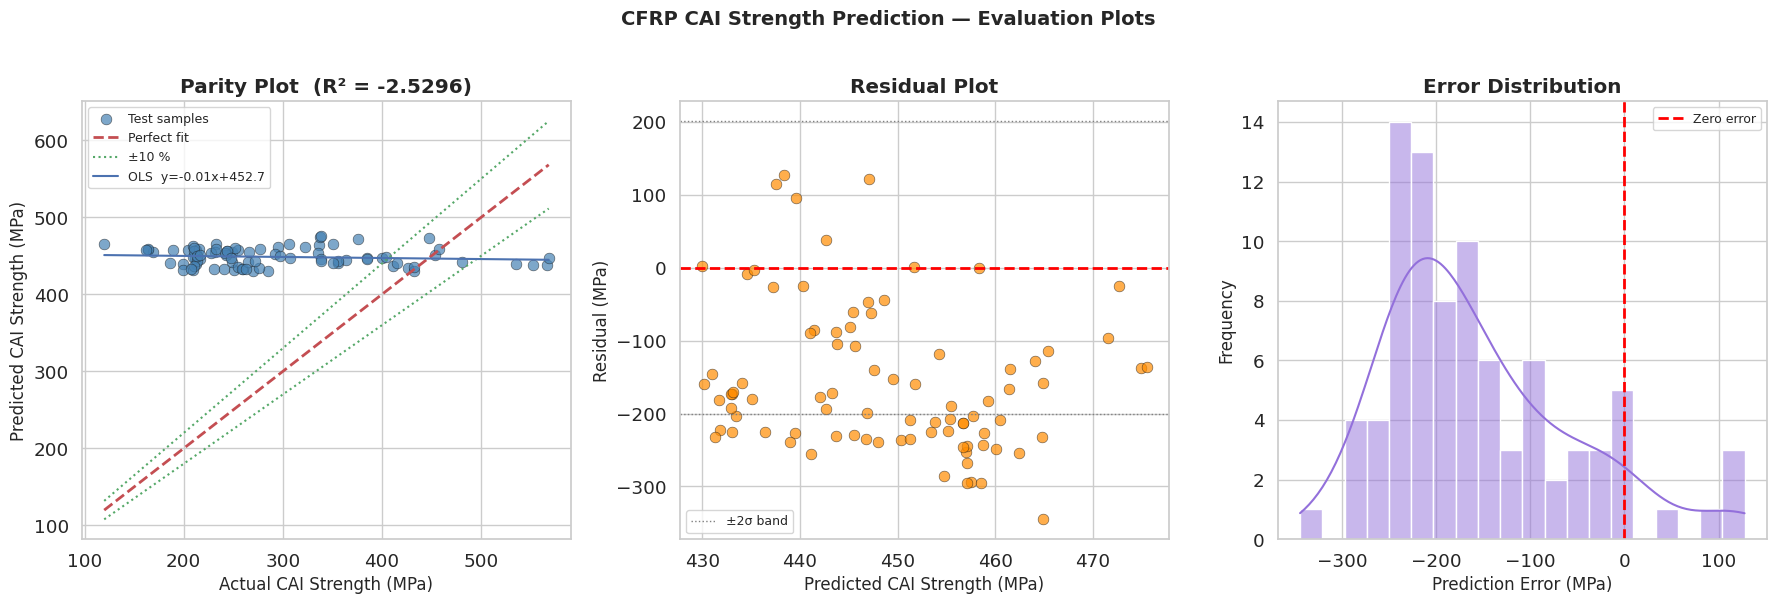

In [66]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── 1. Parity Plot (Predicted vs Actual) ──────────────────────────────────────
ax = axes[0]
lo = min(y_true_mpa.min(), y_pred_mpa.min())
hi = max(y_true_mpa.max(), y_pred_mpa.max())

ax.scatter(y_true_mpa, y_pred_mpa, alpha=0.7, edgecolors='k',
           linewidths=0.4, c='steelblue', s=60, label='Test samples')
ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect fit')

# ±10 % bands
ax.plot([lo, hi], [lo*1.10, hi*1.10], 'g:', lw=1.5, label='±10 %')
ax.plot([lo, hi], [lo*0.90, hi*0.90], 'g:', lw=1.5)

ax.set_xlabel("Actual CAI Strength (MPa)", fontsize=12)
ax.set_ylabel("Predicted CAI Strength (MPa)", fontsize=12)
ax.set_title(f"Parity Plot  (R² = {r2:.4f})", fontweight='bold')
ax.legend(fontsize=9)

# Add regression line
slope, intercept, *_ = stats.linregress(y_true_mpa, y_pred_mpa)
x_line = np.linspace(lo, hi, 100)
ax.plot(x_line, slope*x_line + intercept, 'b-', lw=1.5,
        label=f'OLS  y={slope:.2f}x+{intercept:.1f}')
ax.legend(fontsize=9)

# ── 2. Residuals Plot ─────────────────────────────────────────────────────────
residuals = y_true_mpa - y_pred_mpa
ax = axes[1]
ax.scatter(y_pred_mpa, residuals, alpha=0.7, edgecolors='k',
           linewidths=0.4, c='darkorange', s=60)
ax.axhline(0,  color='red', lw=2, ls='--')
ax.axhline(+2*residuals.std(), color='gray', lw=1, ls=':')
ax.axhline(-2*residuals.std(), color='gray', lw=1, ls=':',
           label='±2σ band')
ax.set_xlabel("Predicted CAI Strength (MPa)", fontsize=12)
ax.set_ylabel("Residual (MPa)", fontsize=12)
ax.set_title("Residual Plot", fontweight='bold')
ax.legend(fontsize=9)

# ── 3. Error Distribution ─────────────────────────────────────────────────────
ax = axes[2]
sns.histplot(residuals, bins=20, kde=True, ax=ax, color='mediumpurple')
ax.axvline(0, color='red', lw=2, ls='--', label='Zero error')
ax.set_xlabel("Prediction Error (MPa)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Error Distribution", fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle("CFRP CAI Strength Prediction — Evaluation Plots",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=150, bbox_inches='tight')
plt.show()

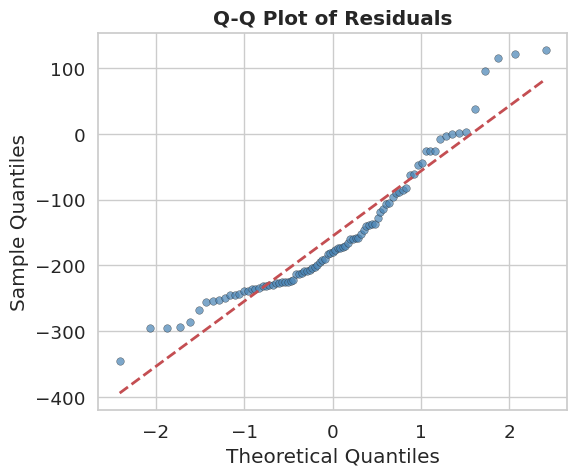

Shapiro-Wilk test: W=0.9215, p=0.0001
  → Residuals deviate from normality (p ≤ 0.05)


In [67]:
# ── Q-Q plot for normality of residuals ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax.scatter(osm, osr, s=30, alpha=0.7, edgecolors='k', lw=0.3, c='steelblue')
ax.plot(osm, slope*np.array(osm)+intercept, 'r--', lw=2)
ax.set_xlabel("Theoretical Quantiles"); ax.set_ylabel("Sample Quantiles")
ax.set_title("Q-Q Plot of Residuals", fontweight='bold')
plt.tight_layout()
plt.savefig("qq_plot.png", dpi=150, bbox_inches='tight')
plt.show()

stat, p_sw = stats.shapiro(residuals)
print(f"Shapiro-Wilk test: W={stat:.4f}, p={p_sw:.4f}")
if p_sw > 0.05:
    print("  → Residuals appear normally distributed (p > 0.05)")
else:
    print("  → Residuals deviate from normality (p ≤ 0.05)")

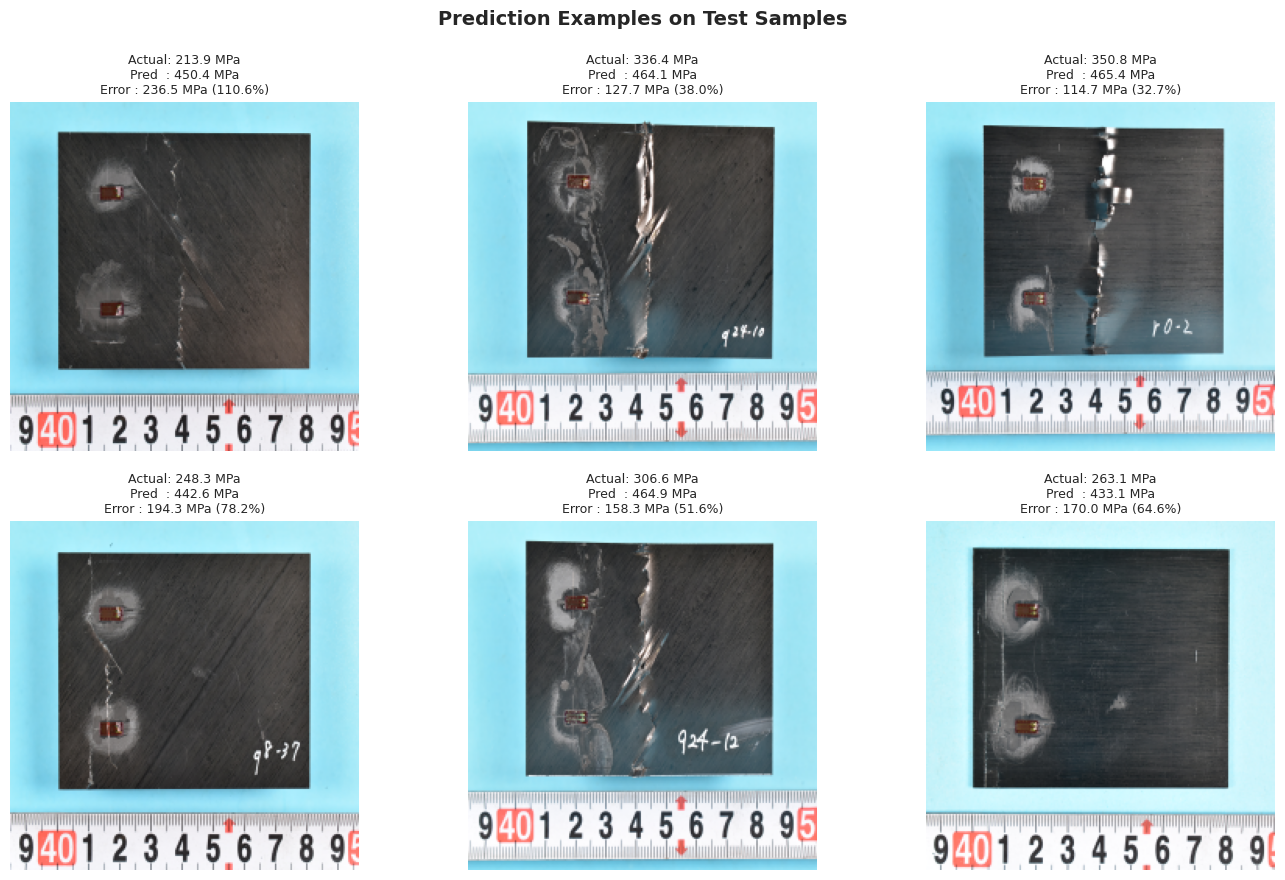

In [68]:
# ── Qualitative prediction examples ───────────────────────────────────────────
n_show = 6
idx = np.random.RandomState(SEED).choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, i in zip(axes.flat, idx):
    img   = X_test[i]                         # already in [0,1]
    act   = y_true_mpa[i]
    pred_v = y_pred_mpa[i]
    err   = abs(act - pred_v)
    pct   = err / act * 100

    ax.imshow(img)
    ax.set_title(
        f"Actual: {act:.1f} MPa\n"
        f"Pred  : {pred_v:.1f} MPa\n"
        f"Error : {err:.1f} MPa ({pct:.1f}%)",
        fontsize=9
    )
    ax.axis('off')

plt.suptitle("Prediction Examples on Test Samples",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("prediction_examples.png", dpi=150, bbox_inches='tight')
plt.show()

In [69]:
metrics_df = pd.DataFrame({
    "Metric" : ["MAE (MPa)", "RMSE (MPa)", "NRMSE (%)", "MAPE (%)", "R²"],
    "Value"  : [f"{mae:.4f}", f"{rmse:.4f}", f"{nrmse:.2f}",
                f"{mape:.2f}", f"{r2:.4f}"],
    "Description": [
        "Mean Absolute Error",
        "Root Mean Squared Error",
        "Normalised RMSE (as % of range)",
        "Mean Absolute Percentage Error",
        "Coefficient of Determination"
    ]
})

print("\n" + "=" * 62)
print("   SUMMARY OF TEST-SET PERFORMANCE (MobileNetV2 Regression)")
print("=" * 62)
print(metrics_df.to_string(index=False))
print("=" * 62)

# Save as CSV for LaTeX table generation
metrics_df.to_csv("metrics_summary.csv", index=False)
print("\nMetrics saved to metrics_summary.csv")


   SUMMARY OF TEST-SET PERFORMANCE (MobileNetV2 Regression)
    Metric    Value                     Description
 MAE (MPa) 167.0958             Mean Absolute Error
RMSE (MPa) 185.2612         Root Mean Squared Error
 NRMSE (%)    41.31 Normalised RMSE (as % of range)
  MAPE (%)    71.70  Mean Absolute Percentage Error
        R²  -2.5296    Coefficient of Determination

Metrics saved to metrics_summary.csv


In [70]:
import joblib

# Save in modern Keras format (preferred over legacy .h5)
model.save("cfrp_cai_mobilenetv2.keras")

# Save scaler for inference
joblib.dump(scaler, "cai_strength_scaler.pkl")

print("Model saved  : cfrp_cai_mobilenetv2.keras")
print("Scaler saved : cai_strength_scaler.pkl")

Model saved  : cfrp_cai_mobilenetv2.keras
Scaler saved : cai_strength_scaler.pkl
